# 04 — Global ML forecasting

Per-clinic models treat each series as an island. A **global model** pools the
panel and learns one function from features to demand, which changes the
economics and the statistics at once:

- **Statistical strength is shared.** Clinic-specific quirks are encoded as
  features (identity, size, specialty, weekday interactions), so clinics with
  noisy or short history borrow structure from the rest of the network.
- **Cost is constant in the number of series.** One training run serves 12 or
  200 clinics; this is what makes the approach production-realistic.
- **Nonlinearities come free.** Tree ensembles capture the diminishing-returns
  marketing response and holiday interactions that linear exogenous terms
  approximate.

The estimator is scikit-learn's `HistGradientBoostingRegressor` on lagged
demand, rolling statistics, calendar and marketing features. Evaluation reuses
the exact folds from notebook 03.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (11, 4)

In [2]:
from clinic_forecast.data import generate_network_data

data_path = PROJECT_ROOT / "data" / "processed" / "clinic_daily_usage.csv"
if data_path.exists():
    usage = pd.read_csv(data_path, parse_dates=["date"])
else:
    usage = generate_network_data().usage
    usage["date"] = pd.to_datetime(usage["date"])

print(usage.shape)

(17532, 32)


## Leakage discipline

Every feature must be computable on the day the forecast is made:

- Lag features shift by at least one day; rolling statistics are computed on
  *shifted* series so the current value never leaks into its own feature.
- The splitter guarantees training data ends strictly before each test
  window.
- For backtesting we build test-window lag features from actuals that would
  have been observed by forecast time (`predict_known_future`). A production
  deployment forecasting 28 days out would feed predictions back recursively —
  a known gap tracked in the development plan, kept honest here rather than
  hidden.

In [3]:
from clinic_forecast.metrics import compute_metrics
from clinic_forecast.models.baseline import seasonal_naive_forecast
from clinic_forecast.models.ml import GlobalMLForecaster
from clinic_forecast.validation import RollingOriginSplitter

splitter = RollingOriginSplitter(initial_train_days=365 * 3, horizon_days=28, max_folds=3)
splitter.summary(usage)

,fold_id,train_start,train_end,test_start,test_end,train_days,test_days,train_rows,test_rows
0,1,2022-01-01,2024-12-30,2024-12-31,2025-01-27,1095,28,13140,336
1,2,2022-01-01,2025-01-27,2025-01-28,2025-02-24,1123,28,13476,336
2,3,2022-01-01,2025-02-24,2025-02-25,2025-03-24,1151,28,13812,336


## Rolling-origin comparison against the baseline

The model is refit from scratch inside every fold — no information crosses
fold boundaries. Seasonal naive is scored on identical data.

In [4]:
from clinic_forecast.evaluation import evaluate_forecasts

scored_folds = []
for train, test, fold in splitter.split(usage):
    model = GlobalMLForecaster()
    model.fit(train)

    combined = pd.concat([train, test], ignore_index=True).sort_values(["clinic_id", "date"])
    predictions = model.predict_known_future(combined)
    predictions = predictions[predictions["date"] >= fold.test_start]

    scored = test.merge(
        predictions[["clinic_id", "date", "forecast", "model"]],
        on=["clinic_id", "date"], how="inner",
    )
    scored_naive = test.merge(
        seasonal_naive_forecast(train=train, future=test),
        on=["clinic_id", "date"], how="left",
    )
    for frame in (scored, scored_naive):
        frame["fold"] = fold.fold_id
    scored_folds.extend([scored, scored_naive])

scored_folds = pd.concat(scored_folds, ignore_index=True)
fold_metrics = evaluate_forecasts(scored_folds, group_cols=["fold"])
fold_metrics.pivot(index="fold", columns="model", values=["wape", "bias"]).round(2)

wape                         bias               
model global_ml_hgb seasonal_naive global_ml_hgb seasonal_naive
fold                                                           
1             18.31          50.04         -4.05         -37.31
2             17.44          27.09         -4.38          -8.30
3             16.83          27.08         -3.17           8.95

In [5]:
wide = fold_metrics.pivot(index="fold", columns="model", values="wape")
improvement = 1 - wide["global_ml_hgb"] / wide["seasonal_naive"]
print("WAPE improvement over seasonal naive: "
      + ", ".join(f"fold {i}: {v:.0%}" for i, v in improvement.items()))

last_fold_id = scored_folds["fold"].max()
last_scored = scored_folds[
    (scored_folds["fold"] == last_fold_id) & (scored_folds["model"] == "global_ml_hgb")
]

WAPE improvement over seasonal naive: fold 1: 63%, fold 2: 36%, fold 3: 38%


Read the table fold by fold, not just on average:

- The improvement over the naive baseline should hold on *every* fold; a
  model that wins on average but loses on a fold is fragile.
- Compare bias columns. The naive method's bias swings with whichever week it
  happened to copy; the model's bias should be smaller and more stable. Bias
  stability matters more than a point of WAPE for staffing, because
  systematic under-forecasting compounds into chronic understaffing.
- The remaining error is dominated by episode onsets — weeks where demand
  shifted for reasons no calendar or lag feature anticipates. That error is
  structural (notebook 02), not a tuning failure.

## Per-clinic performance

A global model can hide poor performance on individual clinics behind a good
volume-weighted average. The distribution below is the check; in a healthcare
network, consistently mis-served clinics are an operational and equity
problem even when the network number looks fine.

In [6]:
clinic_metrics = (
    evaluate_forecasts(last_scored, group_cols=["clinic_id"])
    .sort_values("wape")
    .reset_index(drop=True)
)
clinic_metrics[["clinic_id", "mae", "rmse", "wape", "bias", "n_obs"]].round(2)

,clinic_id,mae,rmse,wape,bias,n_obs
0,CLINIC_002,15.47,19.16,8.61,-2.56,28
1,CLINIC_007,18.33,21.44,15.87,-4.82,28
2,CLINIC_012,25.24,32.68,16.15,-12.13,28
3,CLINIC_004,9.19,13.46,16.30,1.34,28
4,CLINIC_006,13.49,17.21,16.72,-2.20,28
5,CLINIC_011,14.66,18.20,17.26,-9.55,28
6,CLINIC_008,8.60,11.09,18.36,8.50,28
7,CLINIC_010,18.27,24.12,18.51,6.85,28
8,CLINIC_001,15.60,20.96,21.98,-0.06,28
9,CLINIC_009,16.53,20.74,22.66,-5.79,28


In [7]:
spread = clinic_metrics["wape"].max() / clinic_metrics["wape"].min()
print(f"WAPE spread across clinics (final fold): "
      f"{clinic_metrics['wape'].min():.1f}% to {clinic_metrics['wape'].max():.1f}% "
      f"({spread:.1f}x)")

WAPE spread across clinics (final fold): 8.6% to 31.9% (3.7x)


The spread is real: the hardest clinics carry several times the relative error
of the easiest. Cross-reference with the forecastability table in notebook 02
— the high-CV, episode-prone clinics are the same ones at the bottom here,
which says the model is extracting the structure that exists rather than
underfitting specific clinics.

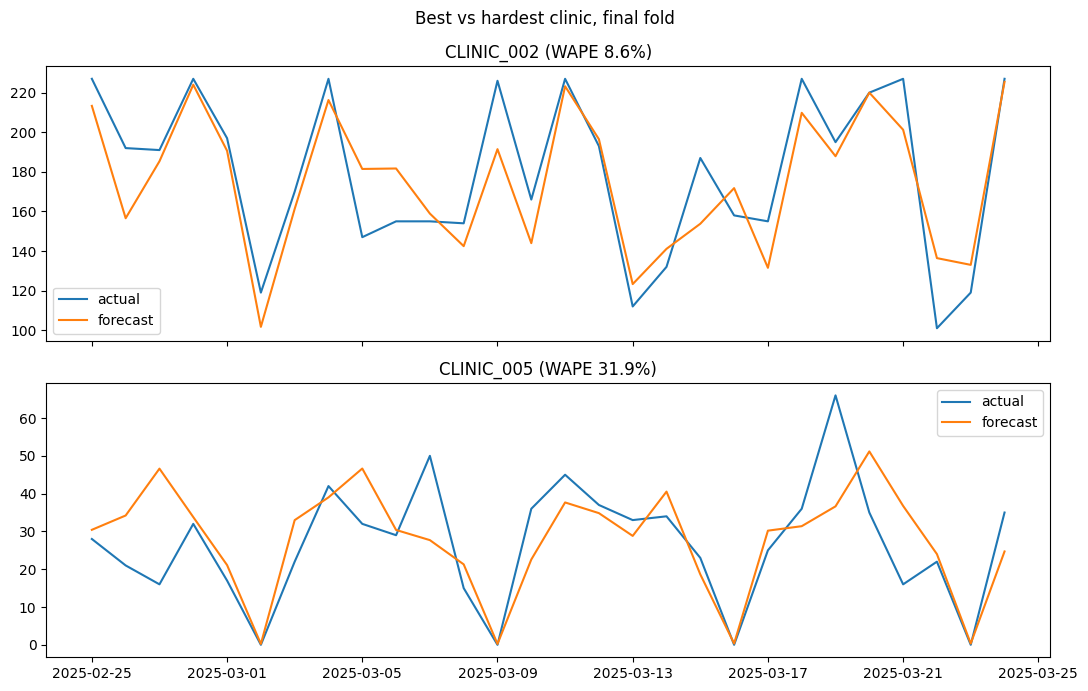

In [8]:
worst = clinic_metrics.iloc[-1]["clinic_id"]
best = clinic_metrics.iloc[0]["clinic_id"]
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, clinic in zip(axes, [best, worst]):
    frame = last_scored[last_scored["clinic_id"] == clinic]
    ax.plot(frame["date"], frame["visits"], label="actual")
    ax.plot(frame["date"], frame["forecast"], label="forecast")
    wape = clinic_metrics.set_index("clinic_id").loc[clinic, "wape"]
    ax.set_title(f"{clinic} (WAPE {wape:.1f}%)")
    ax.legend()
fig.suptitle("Best vs hardest clinic, final fold")
fig.tight_layout()
plt.show()

## Error anatomy: where does the model fail?

Averages hide failure modes. Splitting the final-fold error by day type shows
*when* the model is wrong, which is what an operations team needs to know to
decide where human review is mandatory.

In [9]:
anatomy = last_scored.copy()
anatomy["abs_error"] = (anatomy["forecast"] - anatomy["visits"]).abs()
anatomy["dow"] = anatomy["date"].dt.dayofweek
anatomy["day_type"] = np.select(
    [anatomy["dow"] == 0, anatomy["dow"] < 5, anatomy["dow"] == 5],
    ["monday", "tue-fri", "saturday"], default="sunday",
)
by_day = anatomy.groupby("day_type").agg(
    mean_abs_error=("abs_error", "mean"),
    mean_visits=("visits", "mean"),
)
by_day["relative_error"] = by_day["mean_abs_error"] / by_day["mean_visits"]
by_day.round(2)

,mean_abs_error,mean_visits,relative_error
day_type,,,
monday,18.80,106.08,0.18
saturday,12.81,63.46,0.20
sunday,5.71,30.96,0.18
tue-fri,15.75,98.86,0.16


Errors concentrate where volume and volatility do — Mondays carry the largest
absolute errors but not necessarily the worst relative ones. This shapes the
staffing buffer policy in notebook 06: buffers should scale with day-type
error, not be a flat percentage.

## Optional: XGBoost

The default estimator keeps the core install light. XGBoost (optional group)
is a drop-in alternative; on tabular panels of this size the two are usually
within noise of each other, so the dependency is justified only if its
specific features (monotone constraints, GPU training) are needed.

In [10]:
try:
    from xgboost import XGBRegressor

    print("XGBoost is installed and can replace the default estimator.")
except ImportError:
    print("XGBoost is not installed. Run `poetry install --with optional` to enable it.")

XGBoost is not installed. Run `poetry install --with optional` to enable it.


## Conclusions

1. One global model serves the entire network and beats the seasonal-naive
   floor on every fold, with materially more stable bias.
2. Per-clinic error spread mirrors intrinsic forecastability — the model
   extracts the available structure; what remains is episode-driven.
3. Error concentrates on high-volume Mondays and episode onsets, which is
   exactly where conservative staffing buffers (and, on the roadmap,
   prediction intervals) belong.

**Known gaps, tracked in `docs/development_plan.md`:** true recursive
multi-step prediction for unseen futures, a fitted categorical encoder instead
of re-encoding at predict time, and per-clinic rolling windows in feature
construction.